# Assignment 1: Student Performance Prediction
### Linear Regression on Student Habits & Performance Dataset



## 1. Import Libraries

In [32]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load Dataset

In [33]:
# Load the dataset
df = pd.read_csv("student_habits_performance.csv")

# Display first 5 rows
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [34]:
# Basic information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [35]:
# Shape of the dataset (rows, columns)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 1000
Columns: 16


## 3. Exploratory Data Analysis (EDA)

In [36]:
# Statistical summary of numeric columns
df.describe()


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [37]:
# Check for missing values in each column
df.isnull().sum()


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

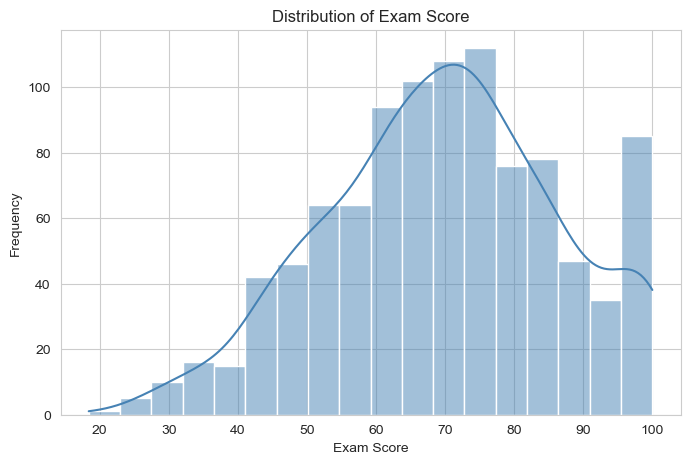

In [38]:
# Distribution of the target variable: exam_score
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], kde=True, color='steelblue')
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()


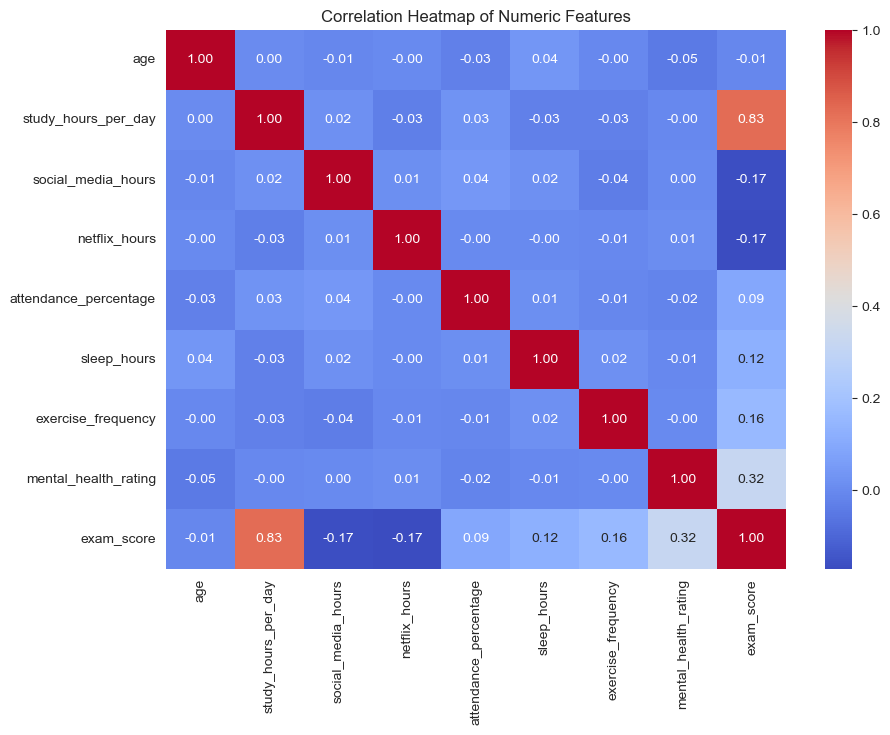

In [39]:
# Correlation heatmap of numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## 4. Data Cleaning & Feature Selection

The assignment requires using the remaining **numeric columns** as features to predict `exam_score`.
So we drop the `student_id` column (identifier, not useful for prediction) and all categorical
(text-based) columns, and keep only numeric columns.


In [40]:
# Select only numeric columns (student_id is an identifier, so it is dropped automatically
# since it is a string column, not numeric)
numeric_df = df.select_dtypes(include=[np.number])

# Confirm which numeric columns we are working with
print("Numeric columns used:")
print(numeric_df.columns.tolist())


Numeric columns used:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']


In [41]:
# Check again for missing values in the numeric subset
numeric_df.isnull().sum()


age                      0
study_hours_per_day      0
social_media_hours       0
netflix_hours            0
attendance_percentage    0
sleep_hours              0
exercise_frequency       0
mental_health_rating     0
exam_score               0
dtype: int64

In [42]:
# Define features (X) and target (y)
X = numeric_df.drop(columns=['exam_score'])
y = numeric_df['exam_score']

print("Feature columns:", X.columns.tolist())
print("Target column: exam_score")


Feature columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Target column: exam_score


## 5. Train-Test Split

In [43]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 800
Testing samples: 200


## 6. Train the Linear Regression Model

In [44]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [45]:
# View model coefficients (how much each feature affects exam_score)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Intercept:", model.intercept_)
coeff_df


Intercept: 5.9063241740265084


,Feature,Coefficient
1,study_hours_per_day,9.533589
5,sleep_hours,1.989896
7,mental_health_rating,1.952032
6,exercise_frequency,1.315593
4,attendance_percentage,0.145895
0,age,0.052559
3,netflix_hours,-2.316592
2,social_media_hours,-2.701878


## 7. Make Predictions on Test Data

In [46]:
# Predict exam scores for the test set
y_pred = model.predict(X_test)

# Compare actual vs predicted values
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': np.round(y_pred, 2)
})
results_df.head(10)


,Actual,Predicted
0,64.2,66.05
1,72.7,74.48
2,79.0,78.10
3,79.5,74.38
4,58.2,61.42
5,53.4,54.83
6,70.8,75.92
7,62.5,55.43
8,36.8,41.61
9,67.6,72.82


## 8. Model Evaluation

In [47]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 30)
print(f"MAE  (Mean Absolute Error)     : {mae:.4f}")
print(f"MSE  (Mean Squared Error)      : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error) : {rmse:.4f}")
print(f"R2 Score                       : {r2:.4f}")


Model Evaluation Metrics
------------------------------
MAE  (Mean Absolute Error)     : 4.1302
MSE  (Mean Squared Error)      : 25.9210
RMSE (Root Mean Squared Error) : 5.0913
R2 Score                       : 0.8989


In [48]:
# Put metrics in a clean summary table
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})
metrics_df


,Metric,Value
0,MAE,4.130186
1,MSE,25.921010
2,RMSE,5.091268
3,R2 Score,0.898915


## 9. Visualize Actual vs Predicted Results

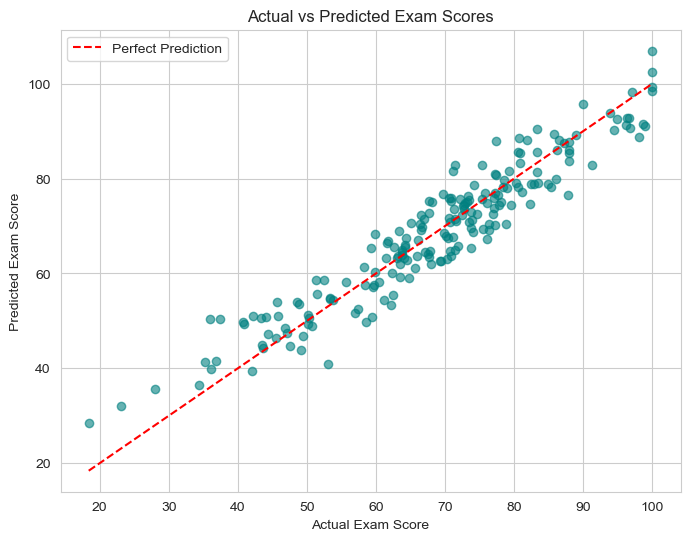

In [49]:
# Scatter plot: Actual vs Predicted exam scores
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.legend()
plt.show()


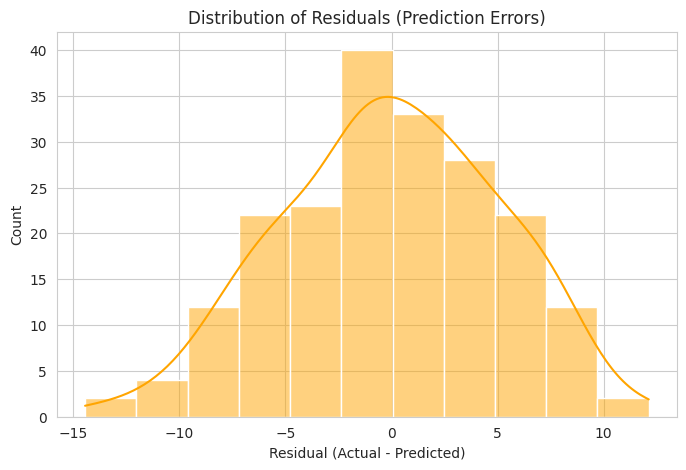

In [19]:
# Residual plot (errors distribution)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='orange')
plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()
